In [3]:
import scipy.stats as scs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


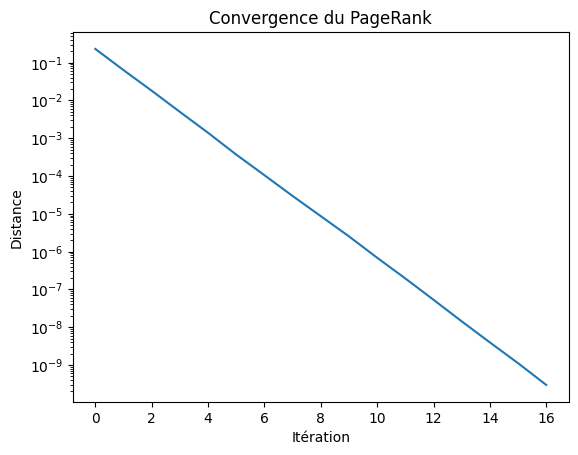

Itération 17, distance = 2.972356847414856e-10


In [4]:
n = 1000 # dimension du graphe
p = 0.01 # probabilité d'avoir une arête entre deux sommets
np.random.seed(2)


# Version moi
# G = np.random.rand(n, n) < p
# # On normalise les lignes du graphe pour obtenir une matrice de transition
# G = G / G.sum(axis=1, keepdims=True)
# Delta = (np.ones((n, n)) -np.eye(n))/(n-1)
# alpha = 0.85
# P = alpha * G + (1-alpha) * Delta

# version chatGPT
A = (np.random.rand(n, n) < p).astype(float)
np.fill_diagonal(A, 0)

row_sums = A.sum(axis=1, keepdims=True)

Delta = (np.ones((n, n)) - np.eye(n)) / (n - 1)

G = np.zeros((n, n))
nonzero = (row_sums[:, 0] > 0)
G[nonzero] = A[nonzero] / row_sums[nonzero]
G[~nonzero] = Delta[~nonzero]

alpha = 0.85
P = alpha * G + (1 - alpha) * Delta


# On initialise le PageRank à 1/n pour chaque sommet
pi = np.ones(n) / n
# On itère jusqu'à convergence
i = 1
distance = []
while True:
    pi_new = P.T @ pi
    distance.append(np.linalg.norm(pi_new - pi, ord=1))
    # print(f'Itération {i}, distance = {distance[-1]}')
    if np.linalg.norm(pi_new - pi, ord=1) < 1e-9:
        plt.plot(distance)
        plt.yscale('log')
        plt.xlabel('Itération')
        plt.ylabel('Distance')
        plt.title('Convergence du PageRank')
        plt.show()
        print(f'Itération {i}, distance = {distance[-1]}')
        pi = pi_new

        break
    pi = pi_new
    i += 1
pi_m = pi

In [5]:
# on fait une régression linéaire sur distance pour avoir les parametres
log_distance = np.log(distance)
X = np.arange(len(distance)).reshape(-1, 1)
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X, log_distance)
print(f'Coefficient de la régression linéaire : {reg.coef_[0]}')
print(f'Ordonnée à l\'origine de la régression linéaire : {reg.intercept_}')
a = reg.coef_[0]
b = reg.intercept_


Coefficient de la régression linéaire : -1.2754350681127198
Ordonnée à l'origine de la régression linéaire : -1.4725209431793935


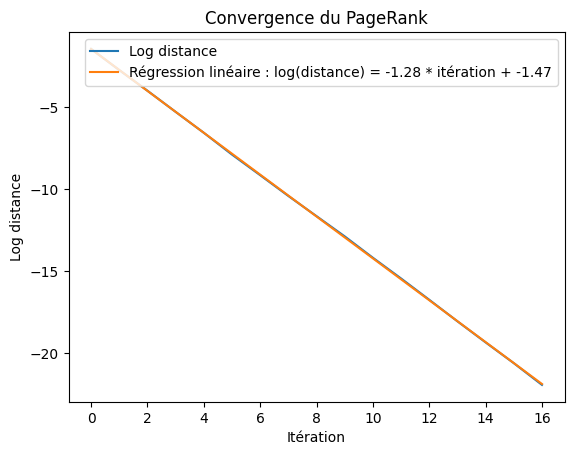

In [6]:
# on plot avec les coeffs trouvés pour vérifier, et on écrit l'équation de la régression linéaire
plt.plot(X, log_distance, label='Log distance')
plt.plot(X, a*X + b, label=f'Régression linéaire : log(distance) = {a:.2f} * itération + {b:.2f}')

plt.xlabel('Itération')
plt.ylabel('Log distance')
plt.title('Convergence du PageRank')
plt.legend()
plt.show()


In [7]:
# ma version de gros neuille
# pi_s = {}
# for k in range(6, 7):
    
#     nb_pas = 10**k
#     position = np.random.randint(n)
#     count_passages = np.zeros(n)
#     count_passages[position]+=1

#     for i in range(nb_pas-1):
#         position = np.random.choice(n, p=P[position])
#         count_passages[position]+=1
#     pi_s[k] = count_passages/nb_pas

In [8]:
# version chatGPT, on utilise la réciproque de la cdf pour simuler le pas
pi_s = {}
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0  # sécurité numérique
for k in range(3, 8):
    np.random.seed(3)
    nb_pas = 10**k
    position = np.random.randint(n)
    count_passages = np.zeros(n)
    count_passages[position]+=1

    for i in range(nb_pas-1):
        u = np.random.rand()
        position = np.searchsorted(cdf[position], u)
        count_passages[position]+=1
    pi_s[k] = count_passages/nb_pas

In [9]:
for k, pi_s_k in pi_s.items():
    print(np.mean(np.abs(pi_s_k-pi)))

0.0008011049041318068
0.0002522773622847773
7.924914622368449e-05
2.5390209763759476e-05
7.680933305211351e-06


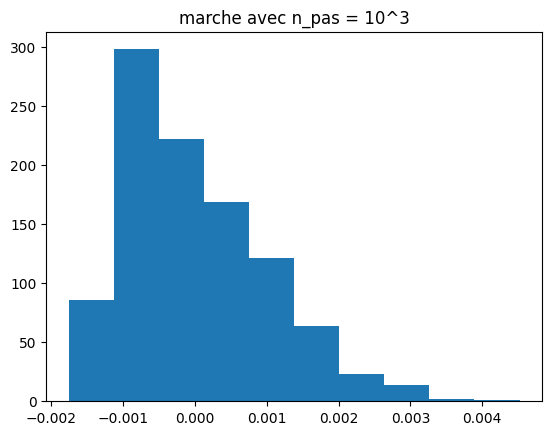

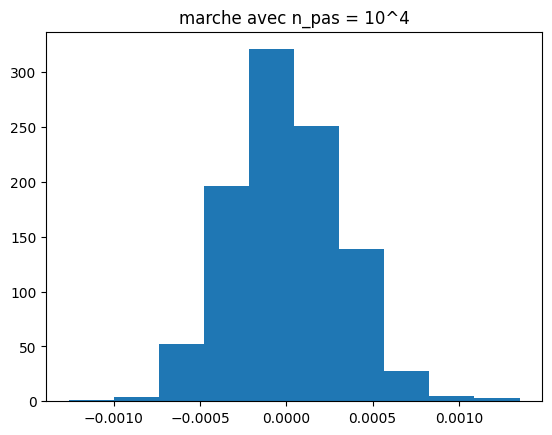

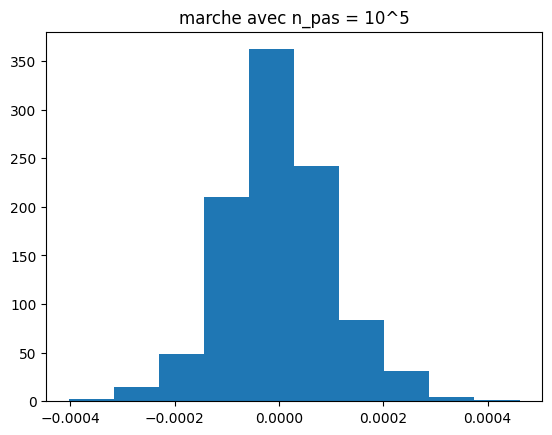

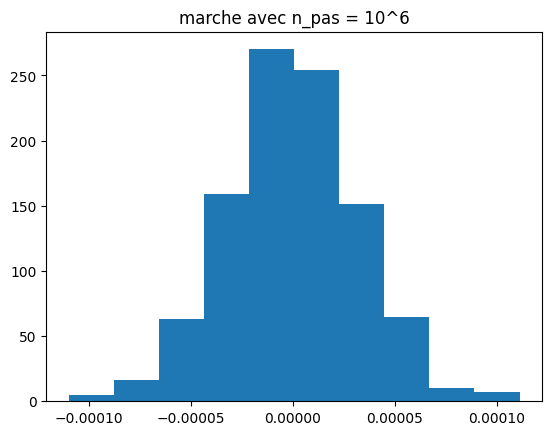

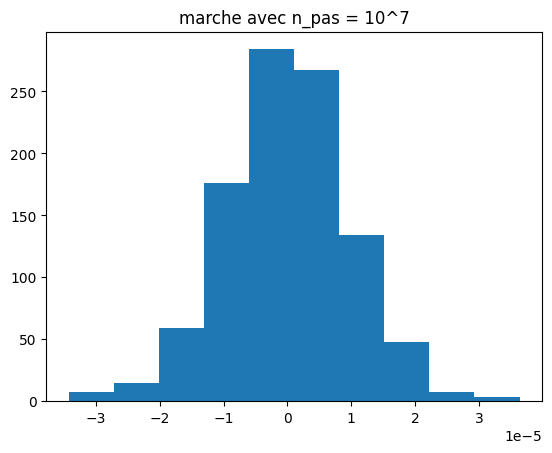

In [10]:
for k, pi_k in pi_s.items():
    plt.hist((pi_k-pi))
    plt.title("marche avec n_pas = 10^"+ str(k))
    plt.show()

In [11]:
sigma_m = np.flip(np.argsort(pi_m))
sigma_s_dico = {k: np.flip(np.argsort(pi_s_k)) for k, pi_s_k in pi_s.items()}
sigma_s = sigma_s_dico.copy()

In [12]:
df = pd.DataFrame({"sigma_m": sigma_m, **{f"sigma_s_{k}": sigma_s_k for k, sigma_s_k in sigma_s.items()}})
df.head(10)

,sigma_m,sigma_s_3,sigma_s_4,sigma_s_5,sigma_s_6,sigma_s_7
0,464,84,555,70,439,464
1,439,652,915,464,209,439
2,209,147,465,920,464,209
3,993,993,285,915,70,993
4,70,366,859,899,993,70
5,332,17,525,439,915,332
6,915,198,250,492,332,915
7,555,226,899,465,555,555
8,225,646,147,555,241,225
9,241,451,973,993,153,920


In [23]:
# distance de Kendall normalisée : 0 = même classement, 1 = classement inversé
def kendall_tau(sigma1, sigma2):
    n = len(sigma1)

    # rang de chaque sommet dans chaque classement
    rank1 = np.empty(n, dtype=int)
    rank2 = np.empty(n, dtype=int)
    rank1[sigma1] = np.arange(n)
    rank2[sigma2] = np.arange(n)

    concordant = 0
    discordant = 0

    for a in range(n):
        for b in range(a + 1, n):
            s1 = rank1[a] - rank1[b]
            s2 = rank2[a] - rank2[b]
            if s1 * s2 > 0:
                concordant += 1
            else:
                discordant += 1

    tau = (concordant - discordant) / (n * (n - 1) / 2)  # dans [-1, 1]
    return (1 - tau) / 2  # distance dans [0, 1]

In [24]:
tau = {}
for k, sigma_s_k in sigma_s.items():
    tau[k] = kendall_tau(sigma_m, sigma_s_k)

In [25]:
tau

{3: 0.42216616616616615,
 4: 0.2692632632632633,
 5: 0.10441841841841842,
 6: 0.0342702702702703,
 7: 0.010558558558558584}

In [27]:
def spearman_distance(sigma1, sigma2):
    n = len(sigma1)
    rank1 = (np.argsort(sigma1))
    rank2 = (np.argsort(sigma2))
    distance = np.abs(rank1 - rank2).sum() / (n**2 //2) # normalisation pour que la distance soit entre 0 et 1
    return distance

In [28]:
print(spearman_distance(np.array(range(6)), np.array(range(6))))
print(spearman_distance(np.array(range(6)), np.array(range(5, -1, -1))))

0.0
1.0


In [29]:
len(sigma_m)

1000

In [30]:
spearman_dis = {}
for k, sigma_s_k in sigma_s.items():
    spearman_dis[k] = spearman_distance(sigma_m, sigma_s_k)

In [31]:
spearman_dis

{3: np.float64(0.574416),
 4: np.float64(0.377072),
 5: np.float64(0.146388),
 6: np.float64(0.04892),
 7: np.float64(0.015668)}

In [32]:
spearman_dis_page1 = {}
for k, sigma_s_k in sigma_s.items():
    spearman_dis_page1[k] = spearman_distance(sigma_m[20:], sigma_s_k[20:])

In [33]:
spearman_dis_page1

{3: np.float64(0.6127571845064557),
 4: np.float64(0.6074552269887546),
 5: np.float64(0.4724364847980008),
 6: np.float64(0.38043731778425655),
 7: np.float64(0.016305705955851728)}

In [ ]:
def weighted_kendall_distance(sigma_true, sigma_est, weight="inverse"):
    n = len(sigma_true)

    rank_true = np.empty(n, dtype=int)
    rank_est = np.empty(n, dtype=int)

    rank_true[sigma_true] = np.arange(n)
    rank_est[sigma_est] = np.arange(n)

    concordant = 0.0
    discordant = 0.0

    for a in range(n):
        for b in range(a + 1, n):
            i = min(rank_true[a], rank_true[b]) + 1

            if weight == "inverse":
                w = 1.0 / i
            elif weight == "inverse_square":
                w = 1.0 / (i ** 2)
            elif weight == "log":
                w = 1.0 / np.log2(i + 1)
            else:
                w = 1.0

            s_true = rank_true[a] - rank_true[b]
            s_est = rank_est[a] - rank_est[b]

            if s_true * s_est > 0:
                concordant += w
            else:
                discordant += w

    tau_w = (concordant - discordant) / (concordant + discordant)
    return (1 - tau_w) / 2




np.float64(0.002590867237648453)

In [36]:
for k, sigma_s_k in sigma_s.items():
    print(f"Distance de Kendall pondérée (inverse) pour k={k} : {weighted_kendall_distance(sigma_m, sigma_s_k, weight='inverse')}")
    print(f"Distance de Kendall pondérée (inverse carré) pour k={k} : {weighted_kendall_distance(sigma_m, sigma_s_k, weight='inverse_square')}")
    print(f"Distance de Kendall pondérée (log) pour k={k} : {weighted_kendall_distance(sigma_m, sigma_s_k, weight='log')}")


Distance de Kendall pondérée (inverse) pour k=3 : 0.3033710835885683
Distance de Kendall pondérée (inverse carré) pour k=3 : 0.14484949319285517
Distance de Kendall pondérée (log) pour k=3 : 0.4054094153258904
Distance de Kendall pondérée (inverse) pour k=4 : 0.16380975896158723
Distance de Kendall pondérée (inverse carré) pour k=4 : 0.11679719907943104
Distance de Kendall pondérée (log) pour k=4 : 0.24882254860784409
Distance de Kendall pondérée (inverse) pour k=5 : 0.03288537118466295
Distance de Kendall pondérée (inverse carré) pour k=5 : 0.0039511491484143235
Distance de Kendall pondérée (log) pour k=5 : 0.09115858595079196
Distance de Kendall pondérée (inverse) pour k=6 : 0.009082474213170655
Distance de Kendall pondérée (inverse carré) pour k=6 : 0.0016814608768383477
Distance de Kendall pondérée (log) pour k=6 : 0.029200528172847906
Distance de Kendall pondérée (inverse) pour k=7 : 0.002590867237648453
Distance de Kendall pondérée (inverse carré) pour k=7 : 7.691433713108431e-05

In [ ]:
def weighted_spearman_distance(sigma1, sigma2, weight="inverse"):
    n = len(sigma1)
    rank1 = np.argsort(sigma1)
    rank2 = np.argsort(sigma2)

    total = 0.0
    norm = 0.0

    for i in range(n):
        # position de l'élément i dans sigma1 (le classement de référence)
        pos = rank1[i] + 1  # 1-indexed

        if weight == "inverse":
            w = 1.0 / pos
        elif weight == "inverse_square":
            w = 1.0 / (pos ** 2)
        elif weight == "log":
            w = 1.0 / np.log2(pos + 1)
        else:
            w = 1.0

        total += w * abs(rank1[i] - rank2[i])
        norm += w * (n - 1)  # distance max pour cet élément

    return total / norm


for k, sigma_s_k in sigma_s.items():
    print(f"k={k}: weighted_spearman = {weighted_spearman_distance(sigma_m, sigma_s_k, weight='inverse'):.6f}")

In [38]:
def precision_at_k(sigma_true, sigma_est, k):
    return len(set(sigma_true[:k]) & set(sigma_est[:k])) / k
for i in [10, 20, 50, 200, 500]:
    print(f'Precision at {i}:')
    for k, sigma_s_k in sigma_s.items():
        print(f'k = {k}: {precision_at_k(sigma_m, sigma_s_k, i)}', end='; ')
    print("")

Precision at 10:
k = 3: 0.1; k = 4: 0.2; k = 5: 0.6; k = 6: 0.9; k = 7: 0.9; 
Precision at 20:
k = 3: 0.1; k = 4: 0.2; k = 5: 0.7; k = 6: 0.85; k = 7: 1.0; 
Precision at 50:
k = 3: 0.14; k = 4: 0.36; k = 5: 0.74; k = 6: 0.88; k = 7: 0.98; 
Precision at 200:
k = 3: 0.345; k = 4: 0.555; k = 5: 0.81; k = 6: 0.93; k = 7: 0.975; 
Precision at 500:
k = 3: 0.582; k = 4: 0.744; k = 5: 0.91; k = 6: 0.97; k = 7: 0.99; 
